In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

### Step 1: Data Loading

### About dataset
Data downloaded from: https://www.kaggle.com/datasets/ganjerlawrence/loan-risk-prediction-dataset/data

Description:
- ID: Unique identifier for each loan applicant.
- Age: Age of the loan applicant.
- Income: Income of the loan applicant.
- Home: Home ownership status (Own, Mortgage, Rent).
- Emp_Length: Employment length in years.
- Intent: Purpose of the loan (e.g., education, home improvement).
- Amount: Loan amount applied for.
- Rate: Interest rate on the loan.
- Status: Loan approval status (Fully Paid, Charged Off, Current).
- Percent_Income: Loan amount as a percentage of income.
- Default: Whether the applicant has defaulted on a loan previously (Yes, No).
- Cred_Length: Length of the applicant's credit history.

In [22]:
df = pd.read_csv("Loan prediction mini dataset.csv")
df.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,13116,23,88000,MORTGAGE,2.0,MEDICAL,6625,11.22,0,0.08,Y,3
1,1742,23,30000,RENT,0.0,PERSONAL,1925,12.18,0,0.06,N,2
2,27672,32,160000,MORTGAGE,9.0,DEBTCONSOLIDATION,12000,7.88,0,0.07,N,8
3,24694,29,75000,OWN,3.0,HOMEIMPROVEMENT,12000,7.51,0,0.16,N,5
4,1994,22,28800,RENT,2.0,VENTURE,14000,7.90,1,0.49,N,2


### Step 2: Data Exploration & Clearning

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8145 entries, 0 to 8144
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              8145 non-null   int64  
 1   Age             8145 non-null   int64  
 2   Income          8145 non-null   int64  
 3   Home            8145 non-null   object 
 4   Emp_length      7909 non-null   float64
 5   Intent          8145 non-null   object 
 6   Amount          8145 non-null   int64  
 7   Rate            7383 non-null   float64
 8   Status          8145 non-null   int64  
 9   Percent_income  8145 non-null   float64
 10  Default         8145 non-null   object 
 11  Cred_length     8145 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 763.7+ KB


In [24]:
print(df['Home'].unique())
print(df['Intent'].unique())
print(df['Default'].unique())

['MORTGAGE' 'RENT' 'OWN' 'OTHER']
['MEDICAL' 'PERSONAL' 'DEBTCONSOLIDATION' 'HOMEIMPROVEMENT' 'VENTURE'
 'EDUCATION']
['Y' 'N']


In [25]:
df = df.astype({
    'Id': 'string',
    'Home': 'category',
    'Intent': 'category',
})
print(df.dtypes)

Id                string[python]
Age                        int64
Income                     int64
Home                    category
Emp_length               float64
Intent                  category
Amount                     int64
Rate                     float64
Status                     int64
Percent_income           float64
Default                   object
Cred_length                int64
dtype: object


In [26]:
df['Default'] = df['Default'].replace({'Y': True, 'N': False})
#df['Status'] = df['Status'].replace({'1': True, '0': False})
print(df.dtypes)

Id                string[python]
Age                        int64
Income                     int64
Home                    category
Emp_length               float64
Intent                  category
Amount                     int64
Rate                     float64
Status                     int64
Percent_income           float64
Default                     bool
Cred_length                int64
dtype: object


In [28]:
df['Status'] = df['Status'].astype(bool)
print(df.dtypes)

Id                string[python]
Age                        int64
Income                     int64
Home                    category
Emp_length               float64
Intent                  category
Amount                     int64
Rate                     float64
Status                      bool
Percent_income           float64
Default                     bool
Cred_length                int64
dtype: object


In [29]:
df.isnull().sum()

Id                  0
Age                 0
Income              0
Home                0
Emp_length        236
Intent              0
Amount              0
Rate              762
Status              0
Percent_income      0
Default             0
Cred_length         0
dtype: int64

C:\Users\sns2p\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


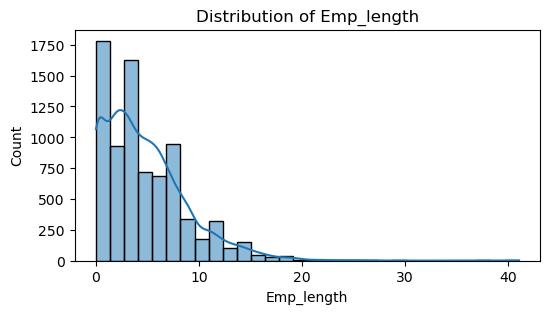

C:\Users\sns2p\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


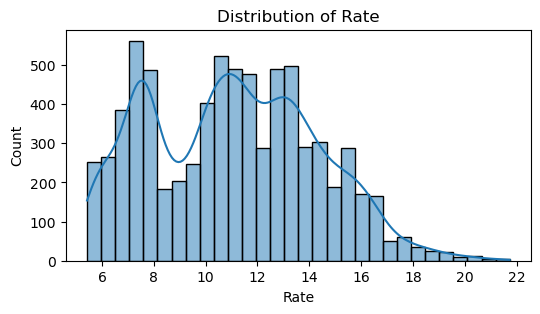

In [30]:
#Check distribution of two dependent variables which include null to determine how to fill missing values

import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Emp_length','Rate']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

In [31]:
#Handle null values

#create new columns for observations that have missing values
df['Emp_length_missing'] = df['Emp_length'].isnull().astype('bool')
df['Rate_missing'] = df['Rate'].isnull().astype('bool')

#Emp_length -> fill median
df['Emp_length'].fillna(df['Emp_length'].median(), inplace=True)

#Rate -> fill by random sampling
missing_idx = df['Rate'].isnull()
df.loc[missing_idx, 'Rate'] = np.random.choice(
    df['Rate'].dropna(), size=missing_idx.sum()
)

In [18]:
df.isnull().sum()

Id                    0
Age                   0
Income                0
Home                  0
Emp_length            0
Intent                0
Amount                0
Rate                  0
Status                0
Percent_income        0
Default               0
Cred_length           0
Emp_length_missing    0
Rate_missing          0
dtype: int64

In [20]:
df.loc[(df['Emp_length_missing']) | (df['Rate_missing'])].head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length,Emp_length_missing,Rate_missing
18,22380,29,55000,MORTGAGE,9.0,HOMEIMPROVEMENT,5000,8.59,False,0.09,False,8,False,True
21,30883,36,35000,RENT,1.0,VENTURE,10000,11.49,False,0.29,False,15,False,True
24,13064,22,90000,RENT,6.0,VENTURE,12000,6.76,False,0.13,False,4,False,True
44,3002,22,30000,RENT,4.0,DEBTCONSOLIDATION,3200,15.62,True,0.11,True,4,True,False
45,12307,26,62900,OWN,4.0,MEDICAL,24250,15.21,True,0.33,True,2,False,True


In [32]:
#Category Encoding
df_label_encoded = df.copy()
df_label_encoded = pd.get_dummies(df, columns=['Home','Intent'], drop_first=True)
df_label_encoded.head()

,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Default,Cred_length,Emp_length_missing,Rate_missing,Home_OTHER,Home_OWN,Home_RENT,Intent_EDUCATION,Intent_HOMEIMPROVEMENT,Intent_MEDICAL,Intent_PERSONAL,Intent_VENTURE
0,13116,23,88000,2.0,6625,11.22,False,0.08,True,3,False,False,False,False,False,False,False,True,False,False
1,1742,23,30000,0.0,1925,12.18,False,0.06,False,2,False,False,False,False,True,False,False,False,True,False
2,27672,32,160000,9.0,12000,7.88,False,0.07,False,8,False,False,False,False,False,False,False,False,False,False
3,24694,29,75000,3.0,12000,7.51,False,0.16,False,5,False,False,False,True,False,False,True,False,False,False
4,1994,22,28800,2.0,14000,7.90,True,0.49,False,2,False,False,False,False,True,False,False,False,False,True


In [39]:
print(len(df))
print(len(df.loc[df['Status'] != df['Default']]))

8145
2166


In [41]:
#drop unnecessary columns
df_label_encoded = df_label_encoded.drop(columns=['Id', 'Status'])

#The Status column was removed because it likely reflects the outcome of the loan and could introduce data leakage when predicting default risk.

In [52]:
df_label_encoded['Default'].value_counts(normalize=True)

Default
False    0.823818
True     0.176182
Name: proportion, dtype: float64

### Step 3: Split dataset into training and test sets

In [54]:
X = df_label_encoded.drop(columns=['Default'])
y = df_label_encoded['Default']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Ensuring reproducibility by fixing the random number generator used in train/test splitting and model training

### Step 4: Modelling
#### Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression

#Build model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

#Prediction
y_pred_logreg = logreg.predict(X_test)
y_prob_logreg = logreg.predict_proba(X_test)[:,1]

In [61]:
from sklearn.metrics import accuracy_score, roc_auc_score

#Evaluation - Accuracy
acc_logreg = accuracy_score(y_test, y_pred_logreg)

#Evaluation - ROC-AUC (to evaluate how well the model ranks high-risk applicants for imbalanced data)
roc_logreg = roc_auc_score(y_test, y_prob_logreg)

print("Logistic Regression Accuracy:", acc_logreg)
print("Logistic Regression ROC-AUC:", roc_logreg)

Logistic Regression Accuracy: 0.8004910988336402
Logistic Regression ROC-AUC: 0.7716406395756332


#### Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

#Build model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

#Prediction
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [64]:
#Evaluation - Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

#Evaluation - ROC-AUC
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", acc_rf)
print("Random Forest ROC-AUC:", roc_rf)

Random Forest Accuracy: 0.8133824432166974
Random Forest ROC-AUC: 0.8630791805122051


Random Forest outperforms Logistic Regression in terms of ROC-AUC (0.863 vs 0.772), indicating it ranks high-risk applicants more accurately. While both models have similar accuracy, ROC-AUC provides a better measure for evaluating prediction quality on imbalanced data, making Random Forest more suitable for identifying applicants at risk of default.

### Insights

#### Top 10 important features identified in Random Forest model

In [65]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head()

Rate                0.391348
Income              0.113329
Amount              0.089834
Percent_income      0.087617
Age                 0.074989
Emp_length          0.068138
Cred_length         0.061050
Rate_missing        0.027499
Home_RENT           0.014526
Intent_EDUCATION    0.013608
dtype: float64

- Interest Rate is the most influential feature, contributing approximately 40% to the Random Forest model's predictions of loan default, highlighting its strong impact on identifying high-risk applicants.
- Other than Interest Rate, Income, Loan Amount, Age, Employment Length, and Credit History are the strongest predictors.

In [70]:
#Look into intent of loans - get average probability of default by loan intent
intent_cols = [c for c in X.columns if 'Intent_' in c]

intent_default_prob = X_test[intent_cols].multiply(y_prob_rf, axis=0).mean()
base_prob = y_prob_rf[ X_test[intent_cols].sum(axis=1) == 0 ].mean()

intent_default_prob['Intent_DEBTCONSOLIDATION'] = base_prob
intent_default_prob = intent_default_prob.sort_values(ascending=False)
print(intent_default_prob)

Intent_DEBTCONSOLIDATION    0.183250
Intent_PERSONAL             0.034834
Intent_EDUCATION            0.033793
Intent_VENTURE              0.031384
Intent_MEDICAL              0.029061
Intent_HOMEIMPROVEMENT      0.023732
dtype: float64


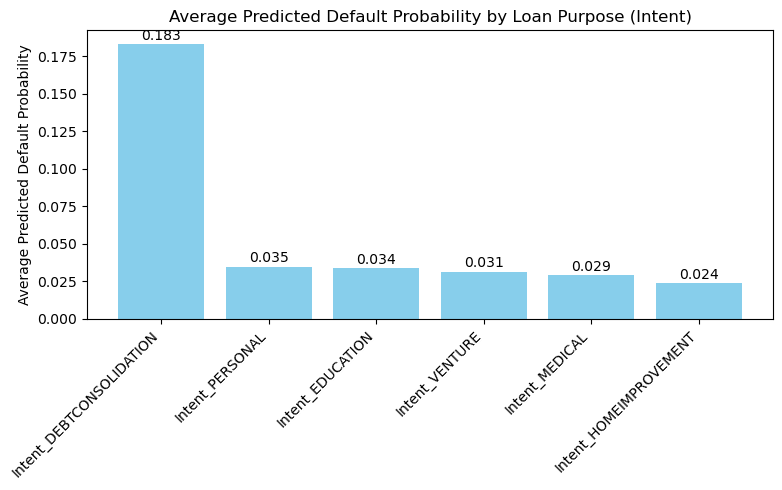

In [75]:
plt.figure(figsize=(8,5))
bars = plt.bar(intent_default_prob.index, intent_default_prob.values, color='skyblue')
plt.ylabel('Average Predicted Default Probability')
plt.title('Average Predicted Default Probability by Loan Purpose (Intent)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.001, f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

DEBTCONSOLIDATION loans have the highest predicted risk, while PERSONAL, EDUCATION, VENTURE, MEDICAL, and HOMEIMPROVEMENT loans show lower risk. This provides insight into which loan purposes may require closer monitoring.